In [1]:
%pip install adjustText

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

from matplotlib.lines import Line2D

from adjustText import adjust_text

In [4]:
activity_files = {
    "SBS": "SBS/Assignment_Solution_Activities.txt",
    "DBS": "DBS/Assignment_Solution_Activities.txt",
    "ID": "ID/Assignment_Solution_Activities.txt"
}

signature_tables = {signature_type: pd.read_csv(path, sep="\t")
                    for signature_type, path in activity_files.items()}

for signature_type, table in signature_tables.items():
    if "Samples" not in table.columns:
        raise ValueError(f"Column 'Samples' was not found in the {signature_type} file.")

    signature_columns = [column for column in table.columns if column.startswith(signature_type)]
    if not signature_columns:
        raise ValueError(f"No {signature_type} signature columns were found.")

    print(f"{signature_type}: {len(table)} samples, {len(signature_columns)} signatures")

SBS: 100 samples, 17 signatures
DBS: 64 samples, 2 signatures
ID: 100 samples, 3 signatures


In [11]:
comparisons = [
    {
        "primary_sample": "SYNG-BC1-1560-FIXT-01-DNA-01_vs_SYNG-BC1-1560-BL_OTHER-01-DNA-01", # Day 0; primary, breast, treatment-naive
        "followup_sample": "SYNG-BC1-1560-FIXT-02-DNA-01_vs_SYNG-BC1-1560-BL_OTHER-01-DNA-01", # Day 0; metastatic, other, non-treatment-naive
        "followup_label": "Metastatic",
        "location": "Other",
        "output": "primary_vs_metastasis1.png"
    },
    {
        "primary_sample": "SYNG-BC1-1563-FIXT-01-DNA-01_vs_SYNG-BC1-1563-BL_OTHER-01-DNA-01", # Day 29; primary, breast, treatment-naive
        "followup_sample": "SYNG-BC1-1563-FIXT-02-DNA-01_vs_SYNG-BC1-1563-BL_OTHER-01-DNA-01", # Day 0; metastatic, other, non-treatment-naive
        "followup_label": "Metastatic",
        "location": "Other",
        "output": "primary_vs_metastasis2.png"
    },
    {
        "primary_sample": 'SYNG-BC1-1565-FIXT-01-DNA-01_vs_SYNG-BC1-1565-BL_OTHER-01-DNA-01', # Day -10; primary, breast, non-treatment-naive
        "followup_sample": 'SYNG-BC1-1565-FIXT-02-DNA-01_vs_SYNG-BC1-1565-BL_OTHER-01-DNA-01', # Day 0; metastatic, other, non-treatment-naive
        "followup_label": "Metastatic",
        "location": "Other",
        "output": "primary_vs_metastasis3.png"
    },
    {
        "primary_sample": 'SYNG-BC1-1573-FIXT-01-DNA-01_vs_SYNG-BC1-1573-BL_OTHER-01-DNA-01', # Day 0; primary, breast, non-treatment-naive
        "followup_sample": 'SYNG-BC1-1573-FIXT-02-DNA-01_vs_SYNG-BC1-1573-BL_OTHER-01-DNA-01', # Day 0; metastatic, other, non-treatment-naive
        "followup_label": "Metastatic",
        "location": "Other",
        "output": "primary_vs_metastasis4.png"
    },
    {
        "primary_sample": 'SYNG-BC1-1575-FIXT-01-DNA-01_vs_SYNG-BC1-1575-BL_OTHER-01-DNA-01', # Day 1; primary, breast, non-treatment-naive
        "followup_sample": 'SYNG-BC1-1575-FIXT-02-DNA-01_vs_SYNG-BC1-1575-BL_OTHER-01-DNA-01', # Day 0; metastatic, other, non-treatment-naive
        "followup_label": "Metastatic",
        "location": "Other",
        "output": "primary_vs_metastasis5.png"
    },
    {
        "primary_sample": 'SYNG-BC1-1584-FIXT-01-DNA-01_vs_SYNG-BC1-1584-BL_OTHER-01-DNA-01', # Day 11; primary, breast, treatment-naive
        "followup_sample": 'SYNG-BC1-1584-FIXT-02-DNA-01_vs_SYNG-BC1-1584-BL_OTHER-01-DNA-01', # Day 0; metastatic, other, non-treatment-naive
        "followup_label": "Metastatic",
        "location": "Other",
        "output": "primary_vs_metastasis6.png"
    }
]

In [6]:
def get_activities(sample_name):
    activities = {}

    for signature_type, table in signature_tables.items():
        rows = table.loc[table["Samples"] == sample_name]

        if rows.empty:
            activities[signature_type] = None
            continue

        if len(rows) > 1:
            raise ValueError(f"Sample '{sample_name}' occurs more than once in the {signature_type} file.")

        signature_columns = [column for column in table.columns if column.startswith(signature_type)]
        activities[signature_type] = rows.iloc[0][signature_columns].astype(float)

    return activities

In [7]:
def get_available_types(primary_data, followup_data):
    return [signature_type for signature_type in ["SBS", "DBS", "ID"]
            if primary_data[signature_type] is not None and followup_data[signature_type] is not None]

In [8]:
def make_comparison_table(primary_data, followup_data, followup_label):
    tables = []

    for signature_type in get_available_types(primary_data, followup_data):
        df = pd.DataFrame({
            "Primary": primary_data[signature_type],
            followup_label: followup_data[signature_type]
        })

        df = df.loc[df.ne(0).any(axis=1)]
        df.insert(0, "Type", signature_type)
        df["Difference"] = df[followup_label] - df["Primary"]
        df.index.name = "Signature"
        tables.append(df.reset_index())

    if not tables:
        return pd.DataFrame(columns=["Signature", "Type", "Primary", followup_label, "Difference"])

    return pd.concat(tables, ignore_index=True)

In [9]:
def scatter_plot(primary_data, followup_data, location, followup_label="Metastatic",
                 relative=False, save_path=None):
    available_types = get_available_types(primary_data, followup_data)
    tables = []

    for signature_type in available_types:
        primary = primary_data[signature_type].copy()
        followup = followup_data[signature_type].copy()

        if relative:
            if primary.sum() > 0:
                primary = primary / primary.sum() * 100
            if followup.sum() > 0:
                followup = followup / followup.sum() * 100

        df_type = pd.DataFrame({"Primary": primary, followup_label: followup})
        df_type = df_type.loc[df_type.ne(0).any(axis=1)]
        tables.append(df_type)

    if not tables:
        raise ValueError("No signature data are available for both samples.")

    df = pd.concat(tables)

    if df.empty:
        raise ValueError("No active signatures were found in either sample.")

    signatures = df.index
    primary_values = df["Primary"].to_numpy()
    followup_values = df[followup_label].to_numpy()
    differences = followup_values - primary_values

    plt.figure(figsize=(12, 8))

    colors = ["red" if difference > 0 else "blue" if difference < 0 else "gray"
              for difference in differences]

    plt.scatter(primary_values, followup_values, c=colors, s=140, alpha=0.75,
                edgecolor="black")

    texts = [plt.text(x, y, signature, fontsize=12)
         for signature, x, y in zip(signatures, primary_values, followup_values)]

    max_value = max(primary_values.max(), followup_values.max())
    plt.plot([0, max_value], [0, max_value], "k--", alpha=0.3)

    axis_suffix = " (%)" if relative else ""
    activity_label = "Relative Signature Activity" if relative else "Signature Activity"

    plt.xlabel(f"Primary{axis_suffix}", fontsize=15, labelpad=10)
    plt.ylabel(f"{followup_label}{axis_suffix}", fontsize=15, labelpad=10)
    plt.title(f"{activity_label} - Primary (Breast) vs {followup_label} ({location})",
              fontsize=14, fontweight="bold")

    plt.scatter([], [], c="red", s=120, label=f"Higher in {followup_label.lower()}")
    plt.scatter([], [], c="blue", s=120, label="Higher in primary")
    plt.scatter([], [], c="gray", s=120, label="No change")
    plt.legend(fontsize=13)

    plt.xticks(fontsize=13)
    plt.yticks(fontsize=13)

    adjust_text(
    texts,
    x=primary_values,
    y=followup_values,
    target_x=primary_values,
    target_y=followup_values,
    expand=(1.2, 1.3),
    arrowprops=dict(arrowstyle="-", color="gray", lw=0.7))

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


Primary vs metastatic (Other)
Available signature types: SBS, DBS, ID


,Signature,Type,Primary,Metastatic,Difference
0,SBS1,SBS,0.0,8.0,8.0
1,SBS3,SBS,0.0,108.0,108.0
2,SBS5,SBS,85.0,20.0,-65.0
3,SBS86,SBS,34.0,0.0,-34.0
4,SBS87,SBS,0.0,12.0,12.0
5,DBS17,DBS,1.0,1.0,0.0
6,ID6,ID,16.0,24.0,8.0


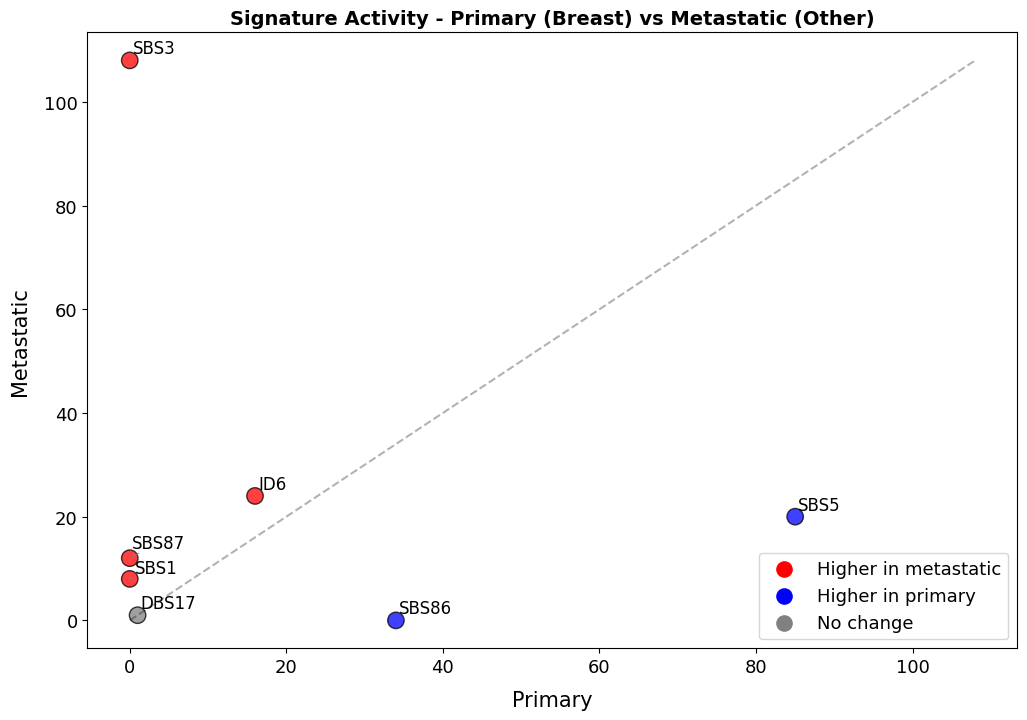


Primary vs metastatic (Other)
Available signature types: SBS, DBS, ID


,Signature,Type,Primary,Metastatic,Difference
0,SBS1,SBS,33.0,39.0,6.0
1,SBS2,SBS,215.0,93.0,-122.0
2,SBS3,SBS,0.0,151.0,151.0
3,SBS5,SBS,153.0,77.0,-76.0
4,SBS13,SBS,478.0,223.0,-255.0
5,DBS2,DBS,1.0,0.0,-1.0
6,DBS17,DBS,3.0,4.0,1.0
7,ID6,ID,28.0,38.0,10.0


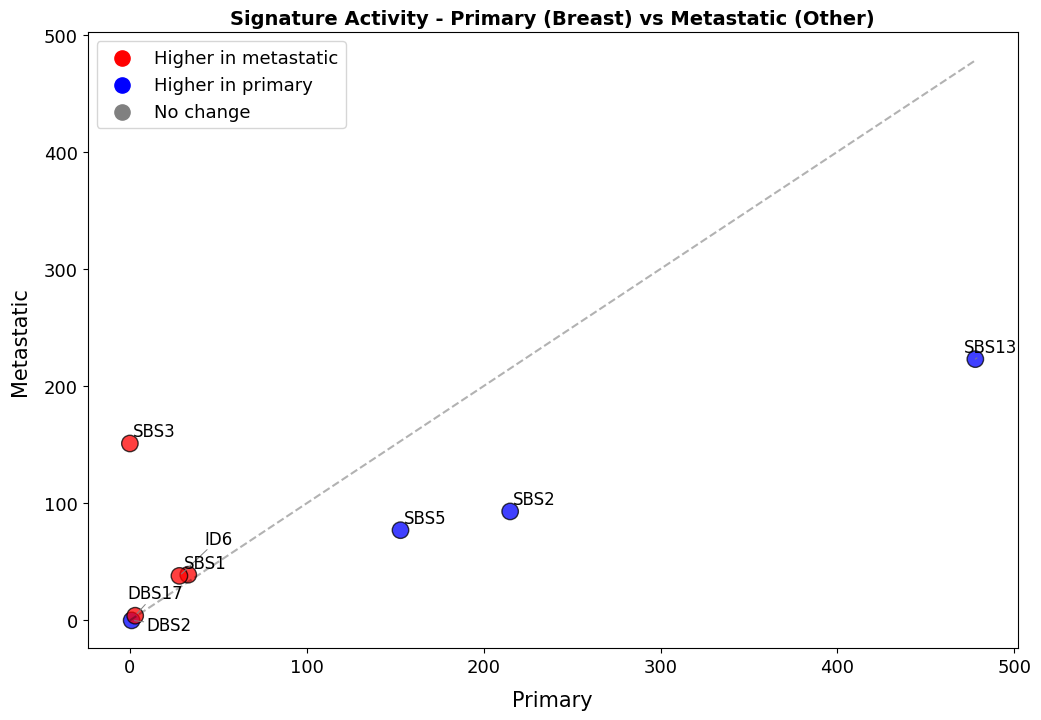


Primary vs metastatic (Other)
Available signature types: SBS, DBS, ID


,Signature,Type,Primary,Metastatic,Difference
0,SBS1,SBS,32.0,126.0,94.0
1,SBS2,SBS,122.0,179.0,57.0
2,SBS5,SBS,262.0,303.0,41.0
3,SBS13,SBS,140.0,119.0,-21.0
4,SBS19,SBS,0.0,174.0,174.0
5,SBS32,SBS,0.0,395.0,395.0
6,DBS2,DBS,2.0,0.0,-2.0
7,DBS17,DBS,0.0,10.0,10.0
8,ID6,ID,34.0,138.0,104.0


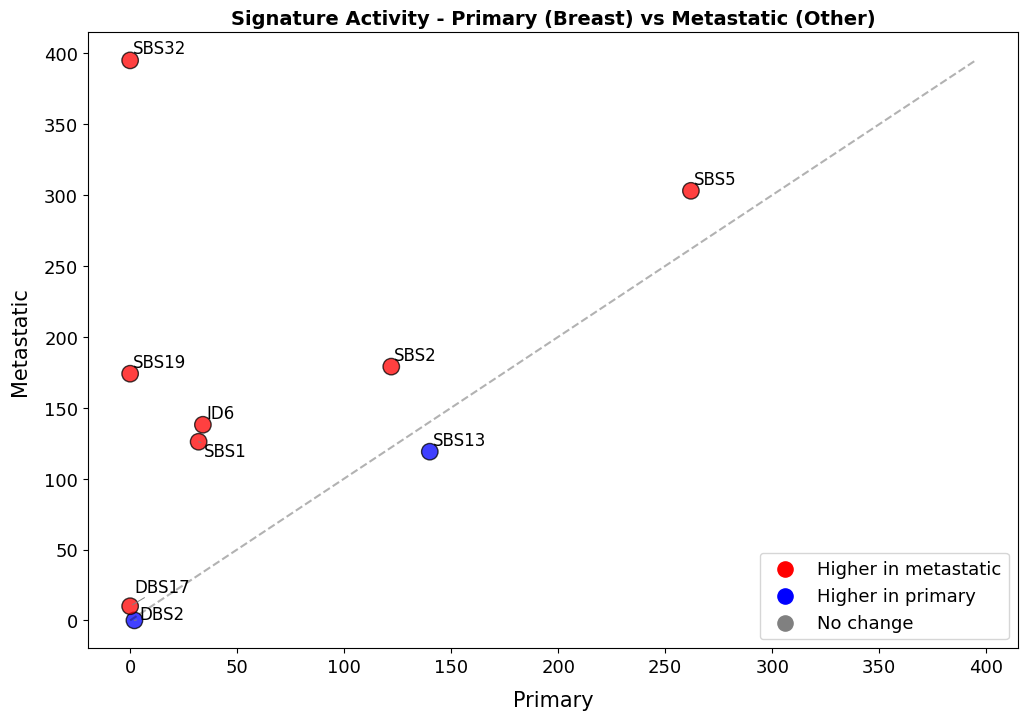


Primary vs metastatic (Other)
Available signature types: SBS, ID
Skipped due to missing sample data: DBS


,Signature,Type,Primary,Metastatic,Difference
0,SBS1,SBS,18.0,15.0,-3.0
1,SBS5,SBS,35.0,22.0,-13.0
2,SBS31,SBS,0.0,13.0,13.0
3,ID8,ID,4.0,5.0,1.0
4,ID9,ID,3.0,0.0,-3.0


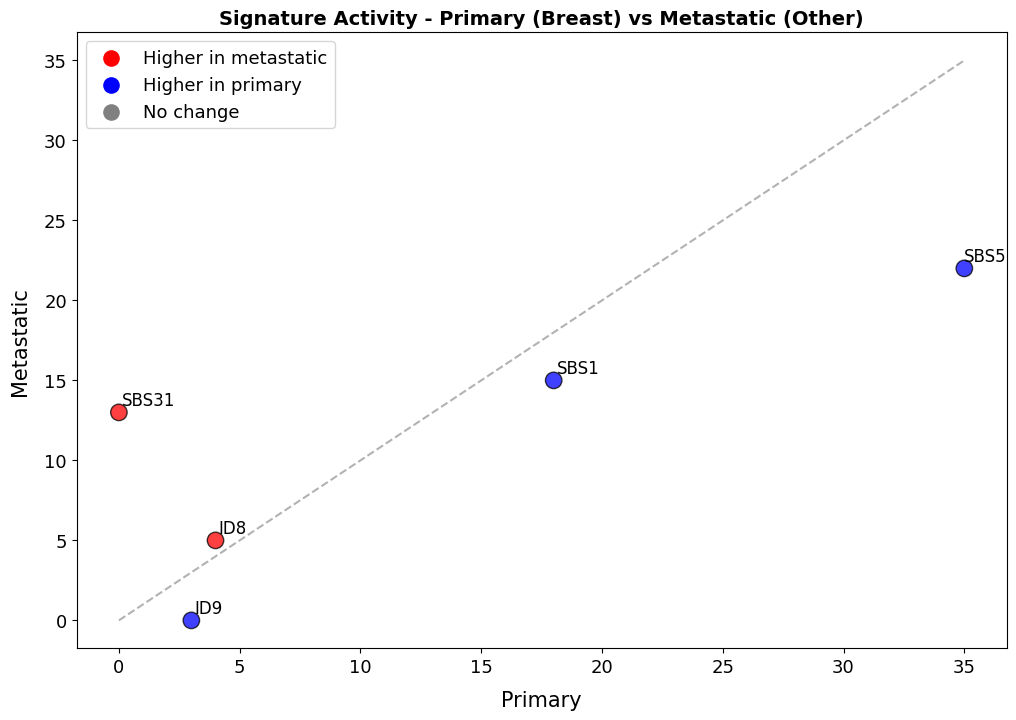


Primary vs metastatic (Other)
Available signature types: SBS, DBS, ID


,Signature,Type,Primary,Metastatic,Difference
0,SBS1,SBS,17.0,19.0,2.0
1,SBS2,SBS,0.0,6.0,6.0
2,SBS5,SBS,136.0,90.0,-46.0
3,SBS13,SBS,0.0,20.0,20.0
4,DBS2,DBS,1.0,2.0,1.0
5,ID6,ID,11.0,0.0,-11.0
6,ID8,ID,0.0,8.0,8.0


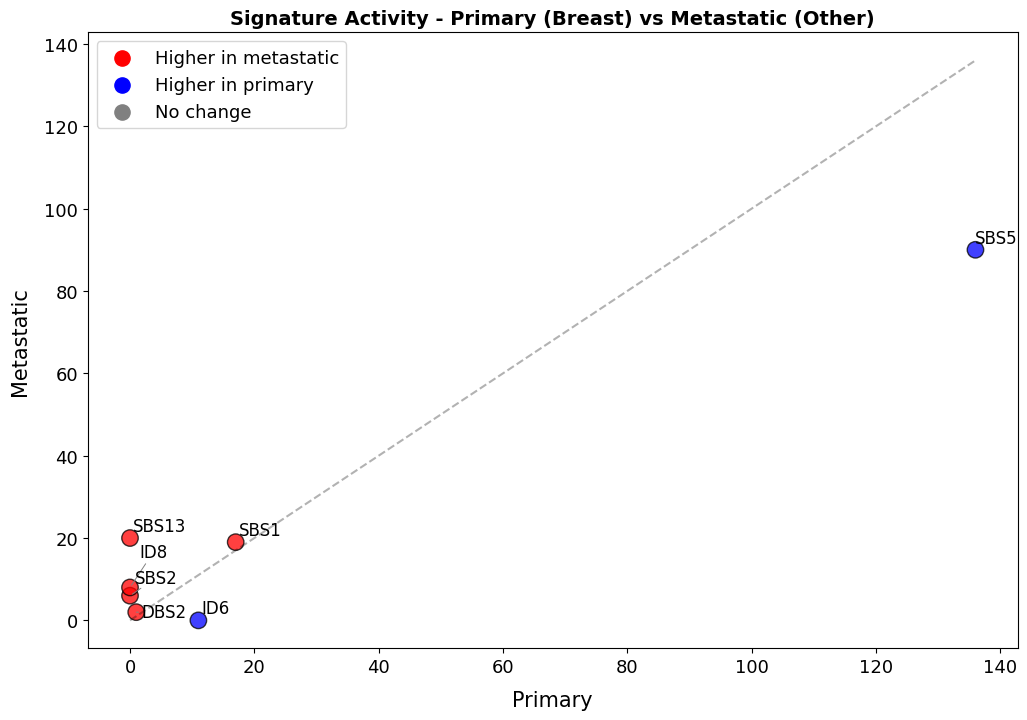


Primary vs metastatic (Other)
Available signature types: SBS, DBS, ID


,Signature,Type,Primary,Metastatic,Difference
0,SBS1,SBS,21.0,32.0,11.0
1,SBS2,SBS,11.0,0.0,-11.0
2,SBS5,SBS,159.0,466.0,307.0
3,SBS13,SBS,19.0,0.0,-19.0
4,DBS17,DBS,1.0,3.0,2.0
5,ID6,ID,32.0,148.0,116.0


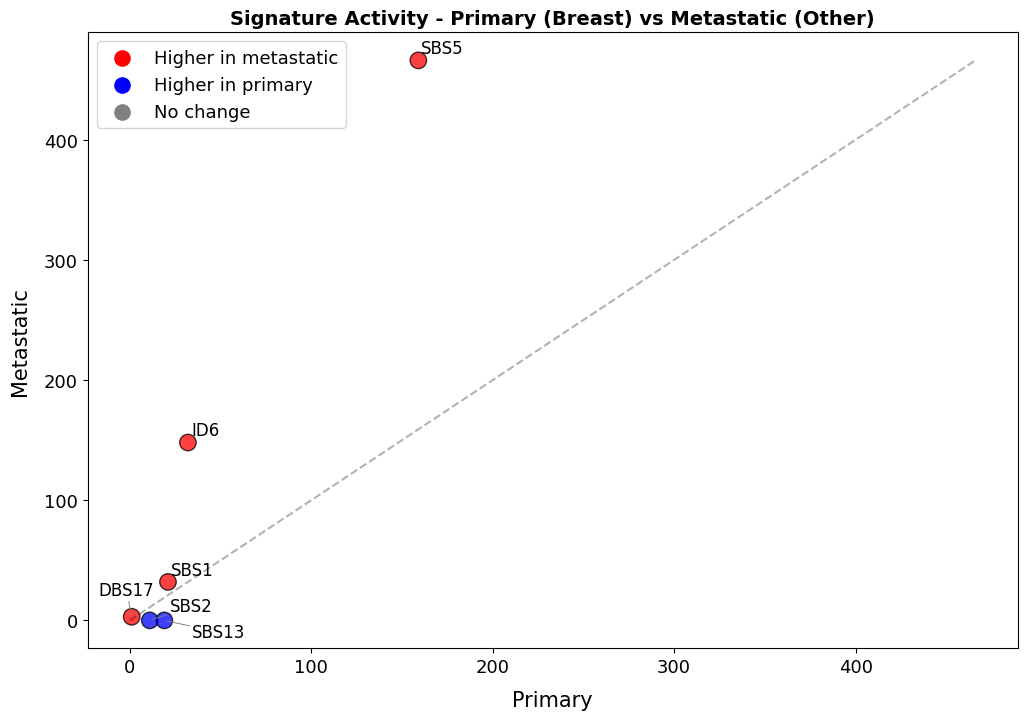

In [12]:
use_relative_activity = False

for comparison in comparisons:
    primary = get_activities(comparison["primary_sample"])
    followup = get_activities(comparison["followup_sample"])

    available_types = get_available_types(primary, followup)
    unavailable_types = [signature_type for signature_type in ["SBS", "DBS", "ID"]
                         if signature_type not in available_types]

    print(f'\nPrimary vs {comparison["followup_label"].lower()} ({comparison["location"]})')
    print(f'Available signature types: {", ".join(available_types)}')

    if unavailable_types:
        print(f'Skipped due to missing sample data: {", ".join(unavailable_types)}')

    display(make_comparison_table(primary, followup, comparison["followup_label"]))

    scatter_plot(primary, followup, comparison["location"],
                 followup_label=comparison["followup_label"],
                 relative=use_relative_activity, save_path=comparison["output"])